# PCA : Principle Component Analysis


PCA (Principal Component Analysis) is a dimensionality reduction technique and helps us to reduce the number of features in a dataset while keeping the most important information. It changes complex datasets by transforming correlated features into a smaller set of uncorrelated components.

here Scaling is important because we need same range of datas

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression

Creating Sample Dataset

In [34]:

data = {
    'Height': [170, 165, 180, 175, 160, 172, 168, 177, 162, 158],
    'Weight': [65, 59, 75, 68, 55, 70, 62, 74, 58, 54],
    'Age': [30, 25, 35, 28, 22, 32, 27, 33, 24, 21],
    'Gender': [1, 0, 1, 1, 0, 1, 0, 1, 0, 0]  # 1 = Male, 0 = Female
}
df = pd.DataFrame(data)
print(df)

   Height  Weight  Age  Gender
0     170      65   30       1
1     165      59   25       0
2     180      75   35       1
3     175      68   28       1
4     160      55   22       0
5     172      70   32       1
6     168      62   27       0
7     177      74   33       1
8     162      58   24       0
9     158      54   21       0


Standardizing the Data  : Since the features have different scales Height vs Age we standardize the data. This makes all features have mean = 0 and standard deviation = 1 so that no feature dominates just because of its units.

In [35]:

X = df.drop("Gender",axis=1)
Y = df["Gender"]

# standarize the data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Applying PCA algorithm

We reduce the data from 3 features to 2 new features called principal components. These components capture most of the original information but in fewer dimensions.

We split the data into 70% training and 30% testing sets.

We train a logistic regression model on the reduced training data and predict gender labels on the test set.

In [36]:
pca = PCA(n_components=2) # n_components = 2 means summerized upto 2 columns

X_pca = pca.fit_transform(X_scaled)

X_train,X_test,Y_train,Y_test = train_test_split(X_pca,Y,test_size=0.3,random_state=42)

model = LogisticRegression()

model.fit(X_train,Y_train)

y_pred = model.predict(X_test)


Evaluating with Confusion Matrix :

The confusion matrix compares actual vs predicted labels. This makes it easy to see where predictions were correct or wrong.

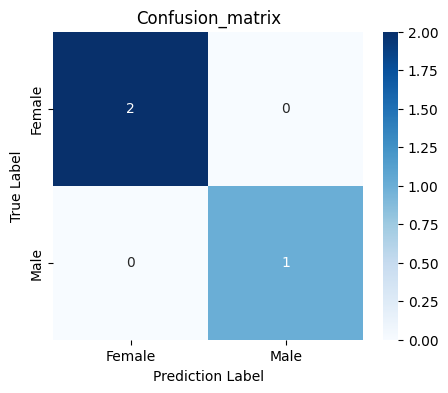

In [37]:
cm = confusion_matrix(Y_test,y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot =True,fmt ='d',cmap="Blues",xticklabels=["Female","Male"],yticklabels=["Female","Male"])
plt.xlabel("Prediction Label")
plt.ylabel("True Label")
plt.title("Confusion_matrix")
plt.show()


Visualizing PCA Result

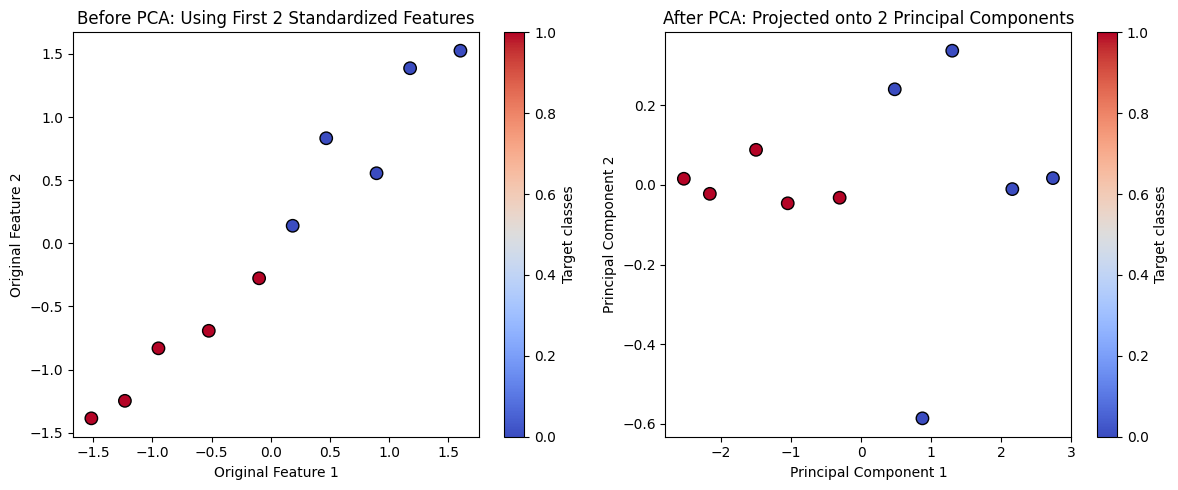

In [38]:
Y_numeric = pd.factorize(Y)[0]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=Y_numeric, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel('Original Feature 1')
plt.ylabel('Original Feature 2')
plt.title('Before PCA: Using First 2 Standardized Features')
plt.colorbar(label='Target classes')

plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=Y_numeric, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('After PCA: Projected onto 2 Principal Components')
plt.colorbar(label='Target classes')

plt.tight_layout()
plt.show()